<a href="https://colab.research.google.com/github/tse-code/ML-AI-Projects/blob/main/RetailRocketRecommenderSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell 1: Install Dependencies & Mount Drive



In [11]:
!pip install --upgrade implicit


from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Cell 2: Imports & Path Definitions

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares

# Adjust these paths to match your actual Drive folder locations
events_path = '/content/drive/MyDrive/retail rocket recommender system/events.csv'
category_path = '/content/drive/MyDrive/retail rocket recommender system/category_tree.csv'
item_props1_path = '/content/drive/MyDrive/retail rocket recommender system/item_properties_part1.csv'
item_props2_path = '/content/drive/MyDrive/retail rocket recommender system/item_properties_part2.csv'


#Cell 3: Load & Quick Inspect

In [14]:
# 1) Load each CSV
df_events   = pd.read_csv(events_path)
df_category = pd.read_csv(category_path)
df_items1   = pd.read_csv(item_props1_path)
df_items2   = pd.read_csv(item_props2_path)

# 2) Show quick info
print("=== EVENTS.CSV ===")
display(df_events.head())
df_events.info()

print("\n=== CATEGORY_TREE.CSV ===")
display(df_category.head())
df_category.info()

print("\n=== ITEM_PROPERTIES_PART1.CSV ===")
display(df_items1.head())
df_items1.info()

print("\n=== ITEM_PROPERTIES_PART2.CSV ===")
display(df_items2.head())
df_items2.info()


=== EVENTS.CSV ===


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB

=== CATEGORY_TREE.CSV ===


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB

=== ITEM_PROPERTIES_PART1.CSV ===


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999999 entries, 0 to 10999998
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 335.7+ MB

=== ITEM_PROPERTIES_PART2.CSV ===


,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9275903 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 283.1+ MB


#Cell 4: Filter & Prepare df_events

In [21]:
# Convert timestamp from ms to datetime
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'], unit='ms')

# Keep only relevant events
valid_events = ['view', 'addtocart', 'transaction']
df_events = df_events[df_events['event'].isin(valid_events)]

# (Optional) filter last 60 days
max_date = df_events['timestamp'].max()
min_date = max_date - pd.Timedelta(days=60)
df_events = df_events[(df_events['timestamp'] >= min_date) & (df_events['timestamp'] <= max_date)]
print("After date filter:", df_events.shape)

# Filter out users/items with fewer than 5 events
user_counts = df_events.groupby('visitorid')['event'].count()
active_users = user_counts[user_counts >= 5].index
df_events = df_events[df_events['visitorid'].isin(active_users)]

item_counts = df_events.groupby('itemid')['event'].count()
popular_items = item_counts[item_counts >= 5].index
df_events = df_events[df_events['itemid'].isin(popular_items)]
print("After user/item filtering:", df_events.shape)

# Create a weight column
def event_to_weight(evt):
    if evt == 'view':
        return 1
    elif evt == 'addtocart':
        return 2
    elif evt == 'transaction':
        return 3
    else:
        return 0

df_events['weight'] = df_events['event'].apply(event_to_weight)

# Time-based split: last 7 days for test
df_events = df_events.sort_values('timestamp')
split_date = df_events['timestamp'].max() - pd.Timedelta(days=7)
df_train = df_events[df_events['timestamp'] < split_date].copy()
df_test  = df_events[df_events['timestamp'] >= split_date].copy()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# Aggregate repeated (visitorid, itemid) pairs
df_train_agg = df_train.groupby(['visitorid','itemid'], as_index=False)['weight'].sum()
df_test_agg  = df_test.groupby(['visitorid','itemid'], as_index=False)['weight'].sum()

print("Train aggregated:", df_train_agg.shape)
print("Test aggregated:", df_test_agg.shape)


After date filter: (278907, 6)
After user/item filtering: (251830, 6)
Train shape: (228522, 6)
Test shape: (23308, 6)
Train aggregated: (112710, 3)
Test aggregated: (12555, 3)


#Label-Encode Items & Users (Train Set)

In [22]:
# Convert itemid to 'category', store the codes
cat_itemid = df_train_agg['itemid'].astype('category')
df_train_agg['item_idx'] = cat_itemid.cat.codes

# Convert visitorid to 'category', store the codes
cat_userid = df_train_agg['visitorid'].astype('category')
df_train_agg['user_idx'] = cat_userid.cat.codes

num_items = df_train_agg['item_idx'].nunique()
num_users = df_train_agg['user_idx'].nunique()
print("num_items =", num_items, " | num_users =", num_users)

# Build item-user dictionary if you want. For evaluation only, we may skip it,
# but let's keep it in case you want to interpret results.
item_idx_to_id = dict(enumerate(cat_itemid.cat.categories))


num_items = 16566  | num_users = 21250


#Build the Item–User Matrix & Train ALS

In [23]:
# 1) Build COO matrix, shape = [num_items, num_users]
coo_train = sp.coo_matrix(
    (
        df_train_agg['weight'],
        (df_train_agg['item_idx'], df_train_agg['user_idx'])
    ),
    shape=(num_items, num_users)
)
item_user_csr = coo_train.tocsr()
print("item_user_csr.shape =", item_user_csr.shape)

# 2) Train ALS on item-user matrix
model_als = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=15,
    random_state=42
)
print("Fitting on item_user_csr with shape:", item_user_csr.shape)
model_als.fit(item_user_csr)

# 3) Inspect shape of learned factors
print("item_factors shape:", model_als.item_factors.shape)  # should be (num_items, 50)
print("user_factors shape:", model_als.user_factors.shape)  # should be (num_users, 50)


item_user_csr.shape = (16566, 21250)
Fitting on item_user_csr with shape: (16566, 21250)


  0%|          | 0/15 [00:00<?, ?it/s]

item_factors shape: (21250, 50)
user_factors shape: (16566, 50)


# Build Test User → Test Items Dictionary

In [24]:
# For evaluation, we only care about user-item pairs that exist in the train mapping

# Build dictionaries for itemid -> item_idx, visitorid -> user_idx
itemid_to_item_idx = dict(zip(cat_itemid.cat.categories, range(len(cat_itemid.cat.categories))))
userid_to_user_idx = dict(zip(cat_userid.cat.categories, range(len(cat_userid.cat.categories))))

# Now gather test interactions in a dictionary: user_idx -> set of item_idx
from collections import defaultdict

test_user_to_items = defaultdict(set)

for row in df_test_agg.itertuples(index=False):
    test_userid = row.visitorid
    test_itemid = row.itemid

    if test_userid in userid_to_user_idx and test_itemid in itemid_to_item_idx:
        u_idx = userid_to_user_idx[test_userid]
        i_idx = itemid_to_item_idx[test_itemid]
        test_user_to_items[u_idx].add(i_idx)

print("Number of users in test set (mapped):", len(test_user_to_items))


Number of users in test set (mapped): 1559


# Build User–Item Matrix for Recommending & Metric Functions

In [27]:
################################################################################
# Convert item_user_csr -> user_item_csr, define evaluation function
################################################################################

user_item_csr = item_user_csr.T  # shape [num_users, num_items]
print("Recommending with user_item_csr:", user_item_csr.shape)

def precision_recall_at_k(model, user_items_matrix, test_dict, k=10, sample_users=1000):
    """
    model: trained ALS model
    user_items_matrix: shape = [num_users, num_items], for .recommend()
    test_dict: dict(user_idx -> set(item_idx)) with test interactions
    k: top-K
    sample_users: number of users to sample for a quick evaluation

    returns: (avg_precision, avg_recall)
    """
    import random

    user_list = list(test_dict.keys())
    if sample_users < len(user_list):
        user_list = random.sample(user_list, sample_users)

    precisions = []
    recalls = []

    for u_idx in user_list:
        true_items = test_dict[u_idx]
        if not true_items:
            continue

        # Single user row from user_items_matrix
        row = user_items_matrix.getrow(u_idx)

        # Capture two arrays: recommended_indices, scores
        recommended_indices, recommended_scores = model.recommend(
            userid=u_idx,
            user_items=row,
            N=k
        )

        # Convert recommended_indices to a set for easy intersection
        recommended_set = set(recommended_indices)
        hits = recommended_set.intersection(true_items)

        prec = len(hits) / k
        rec = len(hits) / len(true_items)

        precisions.append(prec)
        recalls.append(rec)

    avg_precision = np.mean(precisions) if precisions else 0.0
    avg_recall    = np.mean(recalls)    if recalls else 0.0
    return avg_precision, avg_recall


Recommending with user_item_csr: (21250, 16566)


#Evaluate Model Performance

ALS @K=5 => Precision=0.0003, Recall=0.0009
ALS @K=10 => Precision=0.0003, Recall=0.0014
ALS @K=20 => Precision=0.0002, Recall=0.0015


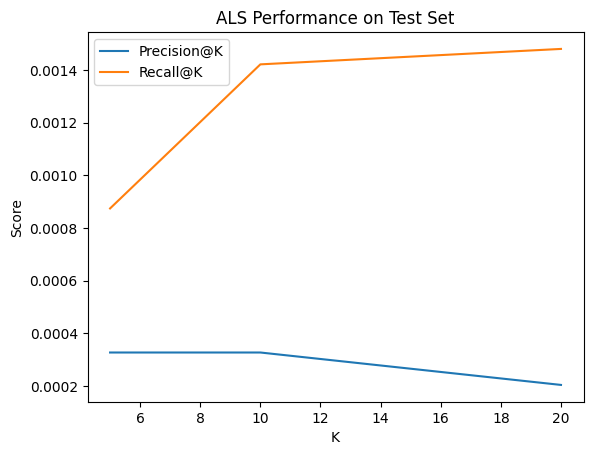

In [33]:
################################################################################
# EVALUATION CELL: Compute Precision@K & Recall@K at different K values
################################################################################

import random
import numpy as np
import matplotlib.pyplot as plt

def precision_recall_at_k(
    model,
    user_items_matrix,
    test_dict,
    k=10,
    sample_users=1000
):
    """
    model: trained ALS model (implicit)
    user_items_matrix: user-item matrix of shape [num_users, num_items]
    test_dict: dict(user_idx -> set(item_idx)) from the test set
    k: number of recommendations to fetch
    sample_users: limit the number of users to evaluate for speed

    returns: (avg_precision, avg_recall) for these K recommendations
    """
    user_list = list(test_dict.keys())
    if sample_users < len(user_list):
        user_list = random.sample(user_list, sample_users)

    # The model has user_factors.shape[0] rows for user vectors
    num_model_users = model.user_factors.shape[0]

    precisions = []
    recalls = []

    for u_idx in user_list:
        # If user index is out of bounds (new/cold user?), skip
        if u_idx >= num_model_users:
            continue

        true_items = test_dict[u_idx]
        if not true_items:
            continue

        # Single row from the user-item matrix
        row = user_items_matrix.getrow(u_idx)

        # ALS .recommend returns (item_indices_array, scores_array)
        recommended_indices, scores = model.recommend(
            userid=u_idx,
            user_items=row,
            N=k
        )

        recommended_set = set(recommended_indices)
        hits = recommended_set.intersection(true_items)

        prec = len(hits) / k
        rec = len(hits) / len(true_items)

        precisions.append(prec)
        recalls.append(rec)

    avg_precision = np.mean(precisions) if precisions else 0.0
    avg_recall    = np.mean(recalls)    if recalls else 0.0
    return avg_precision, avg_recall


# Example usage
ks = [5, 10, 20]
precision_scores = []
recall_scores = []

for k in ks:
    p, r = precision_recall_at_k(
        model=model_als,
        user_items_matrix=user_item_csr,  # shape [num_users, num_items]
        test_dict=test_user_to_items,     # user_idx -> set of item_idx from test
        k=k,
        sample_users=2000                # limit for speed if dataset is large
    )
    precision_scores.append(p)
    recall_scores.append(r)
    print(f"ALS @K={k} => Precision={p:.4f}, Recall={r:.4f}")


# Quick plot of the results
plt.plot(ks, precision_scores, label='Precision@K')
plt.plot(ks, recall_scores, label='Recall@K')
plt.xlabel('K')
plt.ylabel('Score')
plt.title('ALS Performance on Test Set')
plt.legend()
plt.show()
